# Patch Impact Analysis
This notebook presents the outputs of the patch-impact analysis. The analysis is descriptive and does not establish causation.

Run the analysis first from the repository root with `python -m src.analysis.patch_impact`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'reports' / 'results').exists():
    ROOT = Path.cwd().parent
RES = ROOT / 'reports' / 'results'
FIG = ROOT / 'figures' / 'findings'
assert RES.exists(), f'Results directory not found: {RES}'


## Game-level summary and uncertainty

In [2]:
summary = pd.read_csv(RES / 'patch_impact_summary.csv')
display(summary.T.rename(columns={0: 'Value'}))
game_level = pd.read_csv(RES / 'patch_impact_game_level.csv')
print(f'Games represented: {game_level["appid"].nunique():,}')
display(game_level.head())

,Value
games,617.000000
eligible_patch_events,1685.000000
mean_game_level_positive_pct_change,-2.058029
median_game_level_positive_pct_change,-1.250000
bootstrap_95_ci_low,-2.754977
bootstrap_95_ci_high,-1.366947
bootstrap_replicates,10000.000000
random_seed,42.000000
mean_game_level_negative_pct_change,2.058029
mean_game_level_review_volume_change,84.714748


Games represented: 617


,appid,patch_comparisons,mean_positive_pct_change,mean_negative_pct_change,mean_review_volume_change,mean_review_volume_pct_change
0,357330,3,1.507771,-1.507771,-5.0,-12.558758
1,582330,4,-6.633261,6.633261,35.0,154.988036
2,585020,3,-9.936261,9.936261,254.0,691.925926
3,589050,1,0.714286,-0.714286,1.0,5.000000
4,600610,1,-10.058824,10.058824,43.0,172.000000


## Results by time since launch

In [3]:
launch = pd.read_csv(RES / 'patch_impact_by_launch.csv')
display(launch)

,launch_group,patch_comparisons,games,mean_positive_pct_change,median_positive_pct_change,mean_review_volume_change,mean_review_volume_pct_change
0,31–180 days,317,225,-0.761359,-0.721154,-124.996845,41.782335
1,>180 days,751,206,-0.361551,0.000000,56.443409,106.711024
2,≤30 days (including pre-launch),617,570,-1.895995,-1.978022,350.035656,350.199840


## Results by pre-patch positivity

In [4]:
strata = pd.read_csv(RES / 'patch_impact_by_before_positivity.csv')
display(strata)

,before_positive_stratum,patch_comparisons,games,mean_before_positive_pct,mean_positive_pct_change,median_positive_pct_change,mean_review_volume_change
0,70–90%,757,331,82.898582,-0.046022,0.582751,154.015852
1,<70%,105,82,57.753511,9.447263,10.378378,40.990476
2,>90%,823,373,95.302179,-3.207567,-1.918852,118.885784


## Patch-level results

In [5]:
patches = pd.read_csv(RES / 'patch_impact_results.csv', parse_dates=['patch_date'])
print(f'Eligible comparisons: {len(patches):,}')
display(patches.head())

Eligible comparisons: 1,685


,appid,patch_id,patch_date,patch_title,launch_date,days_since_launch,launch_group,before_reviews,after_reviews,before_positive_pct,after_positive_pct,positive_pct_change,before_negative_pct,after_negative_pct,negative_pct_change,review_volume_change,review_volume_pct_change,before_positive_stratum
0,357330,4249665521682799613,2015-04-15 12:41:53+00:00,Early Access Update 1,2015-04-06 19:54:11+00:00,8.699792,≤30 days (including pre-launch),41,26,82.926829,96.153846,13.227017,17.073171,3.846154,-13.227017,-15,-36.585366,70–90%
1,357330,423688416233730544,2015-08-05 18:59:25+00:00,Early Access Update 10,2015-04-06 19:54:11+00:00,120.961968,31–180 days,22,20,100.000000,95.000000,-5.000000,0.000000,5.000000,5.000000,-2,-9.090909,>90%
2,357330,2609208878377111965,2020-01-29 16:07:46+00:00,Early Access Update Femtio (50),2015-04-06 19:54:11+00:00,1758.842766,>180 days,25,27,100.000000,96.296296,-3.703704,0.000000,3.703704,3.703704,2,8.000000,>90%
3,582330,2363696743810678970,2018-02-04 16:58:24+00:00,Hotfix 0.4.0.1 is up!,2018-02-02 10:46:52+00:00,2.258009,≤30 days (including pre-launch),31,96,100.000000,88.541667,-11.458333,0.000000,11.458333,11.458333,65,209.677419,>90%
4,582330,2394102381814703178,2018-04-11 17:49:00+00:00,Patch 0.42 is finally here!,2018-02-02 10:46:52+00:00,68.293148,31–180 days,70,22,84.285714,81.818182,-2.467532,15.714286,18.181818,2.467532,-48,-68.571429,70–90%


## Figures

patch_impact_change_distribution.png


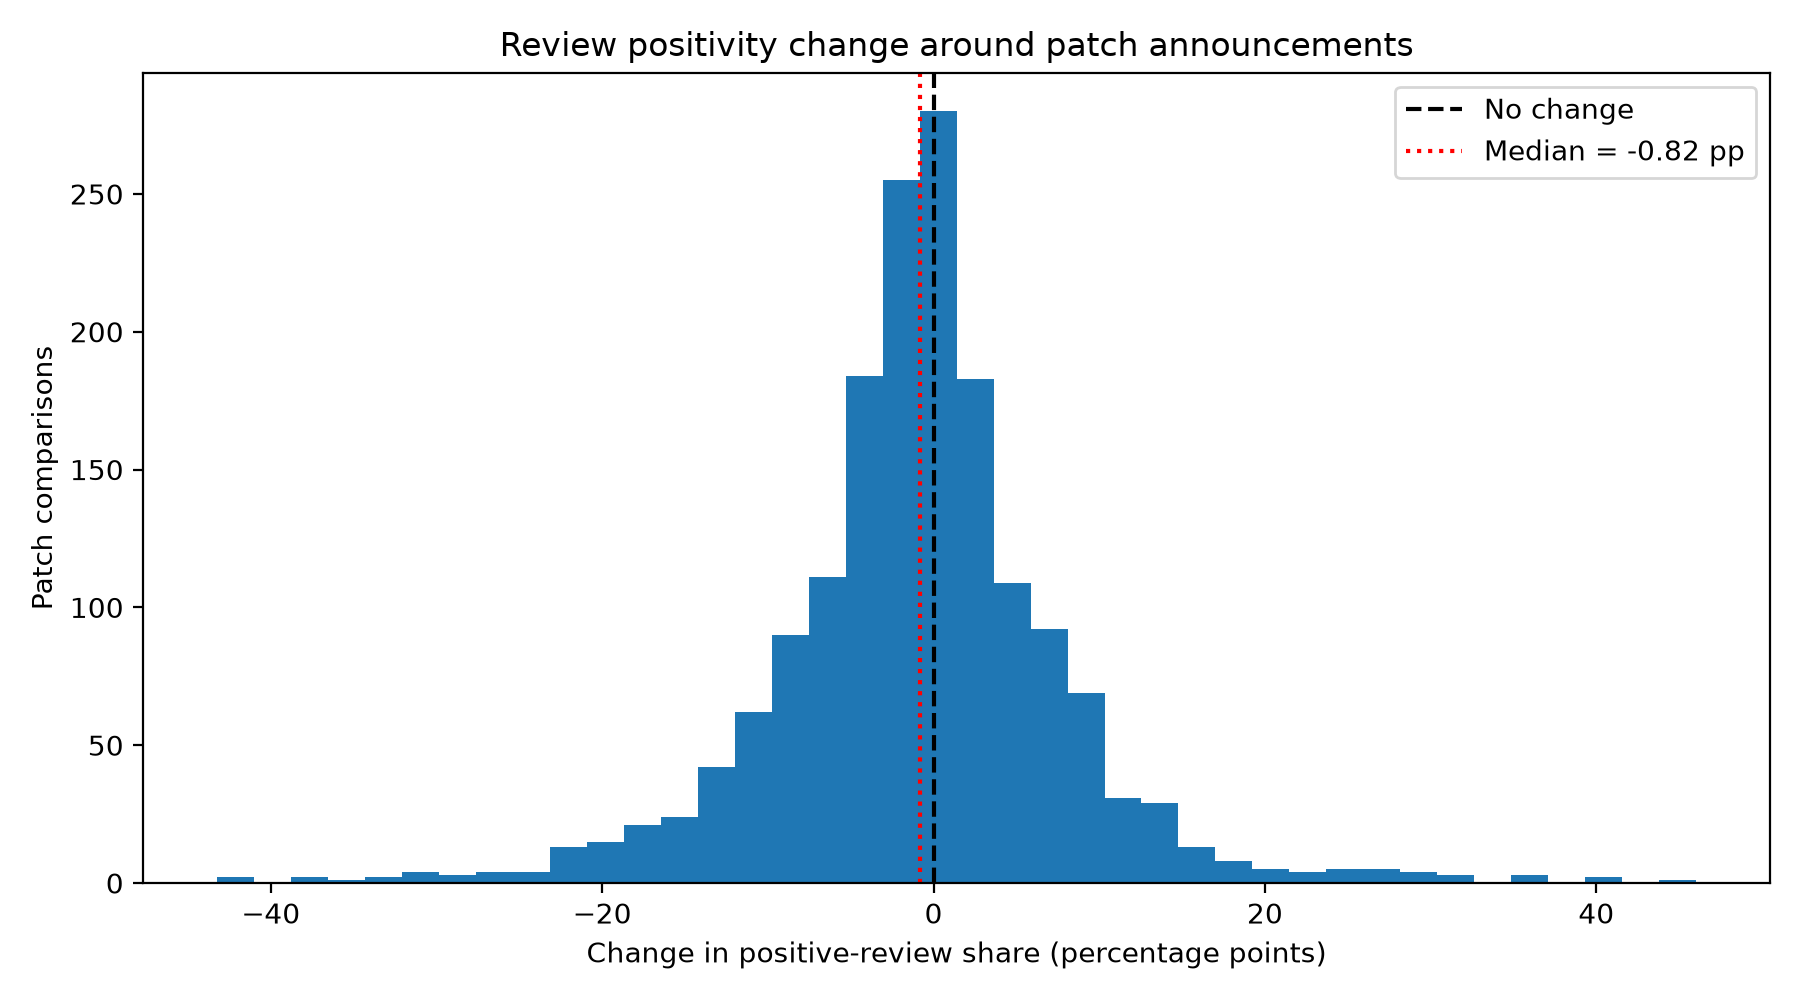

patch_impact_by_launch.png


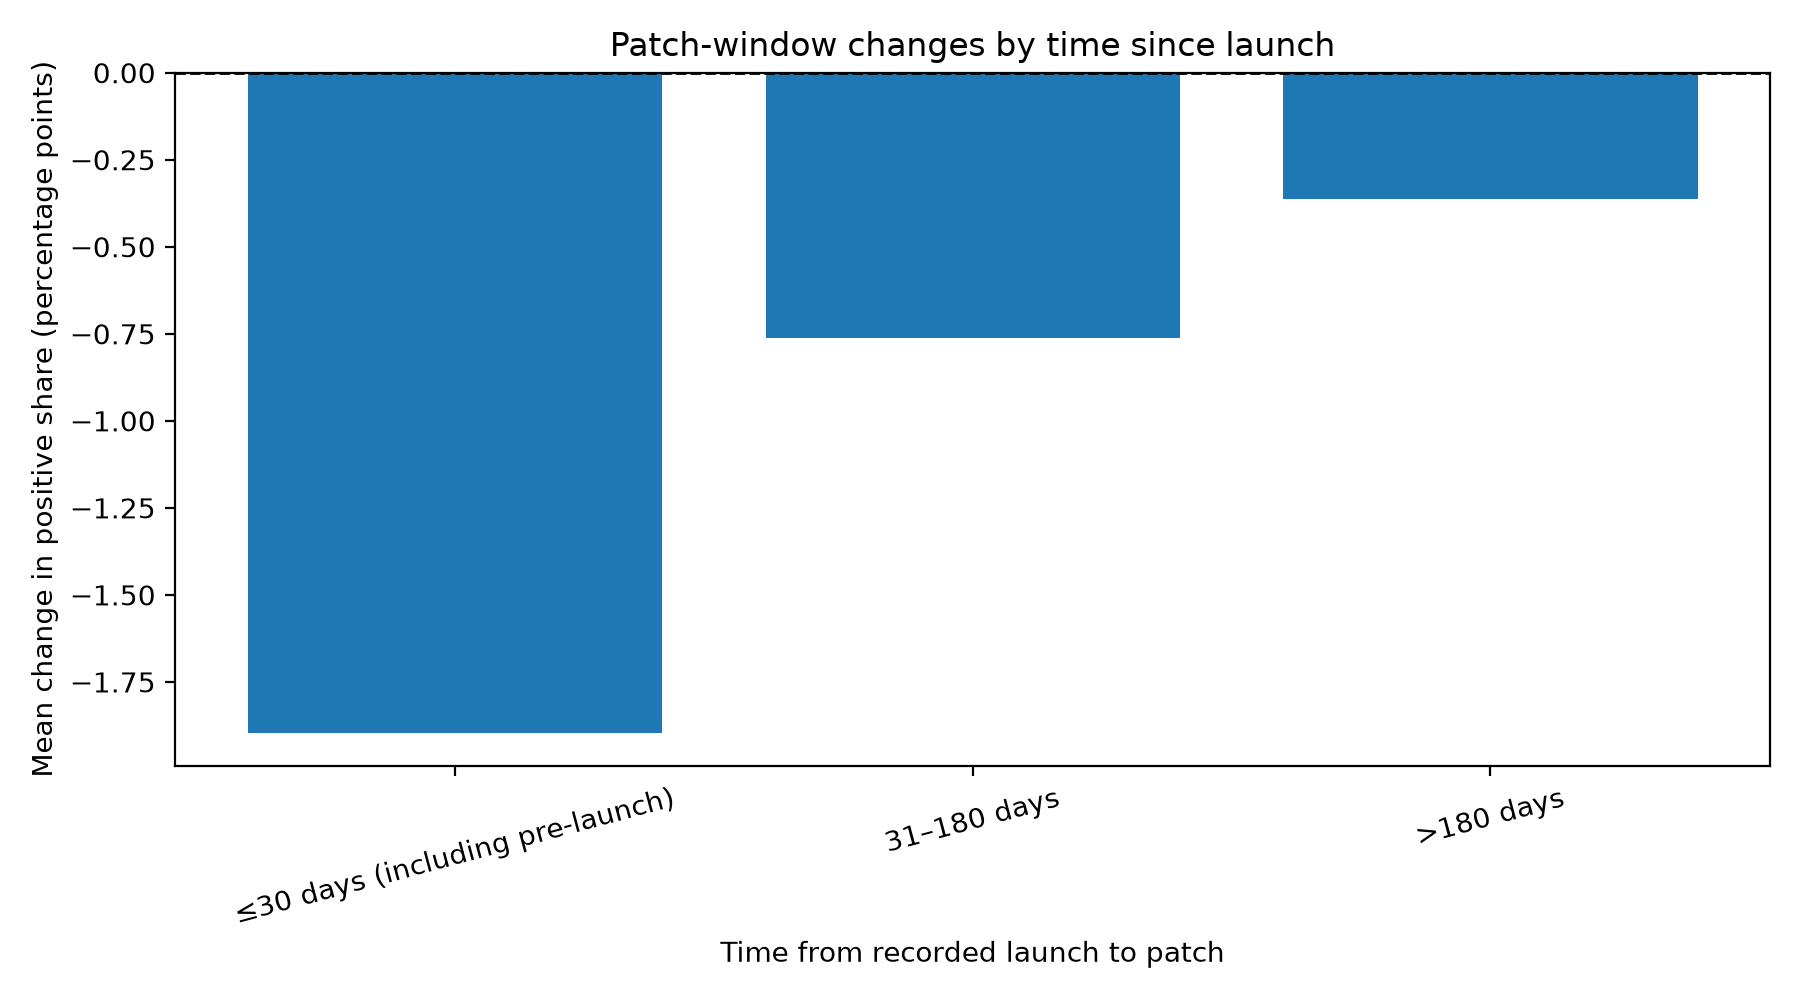

patch_impact_by_before_positivity.png


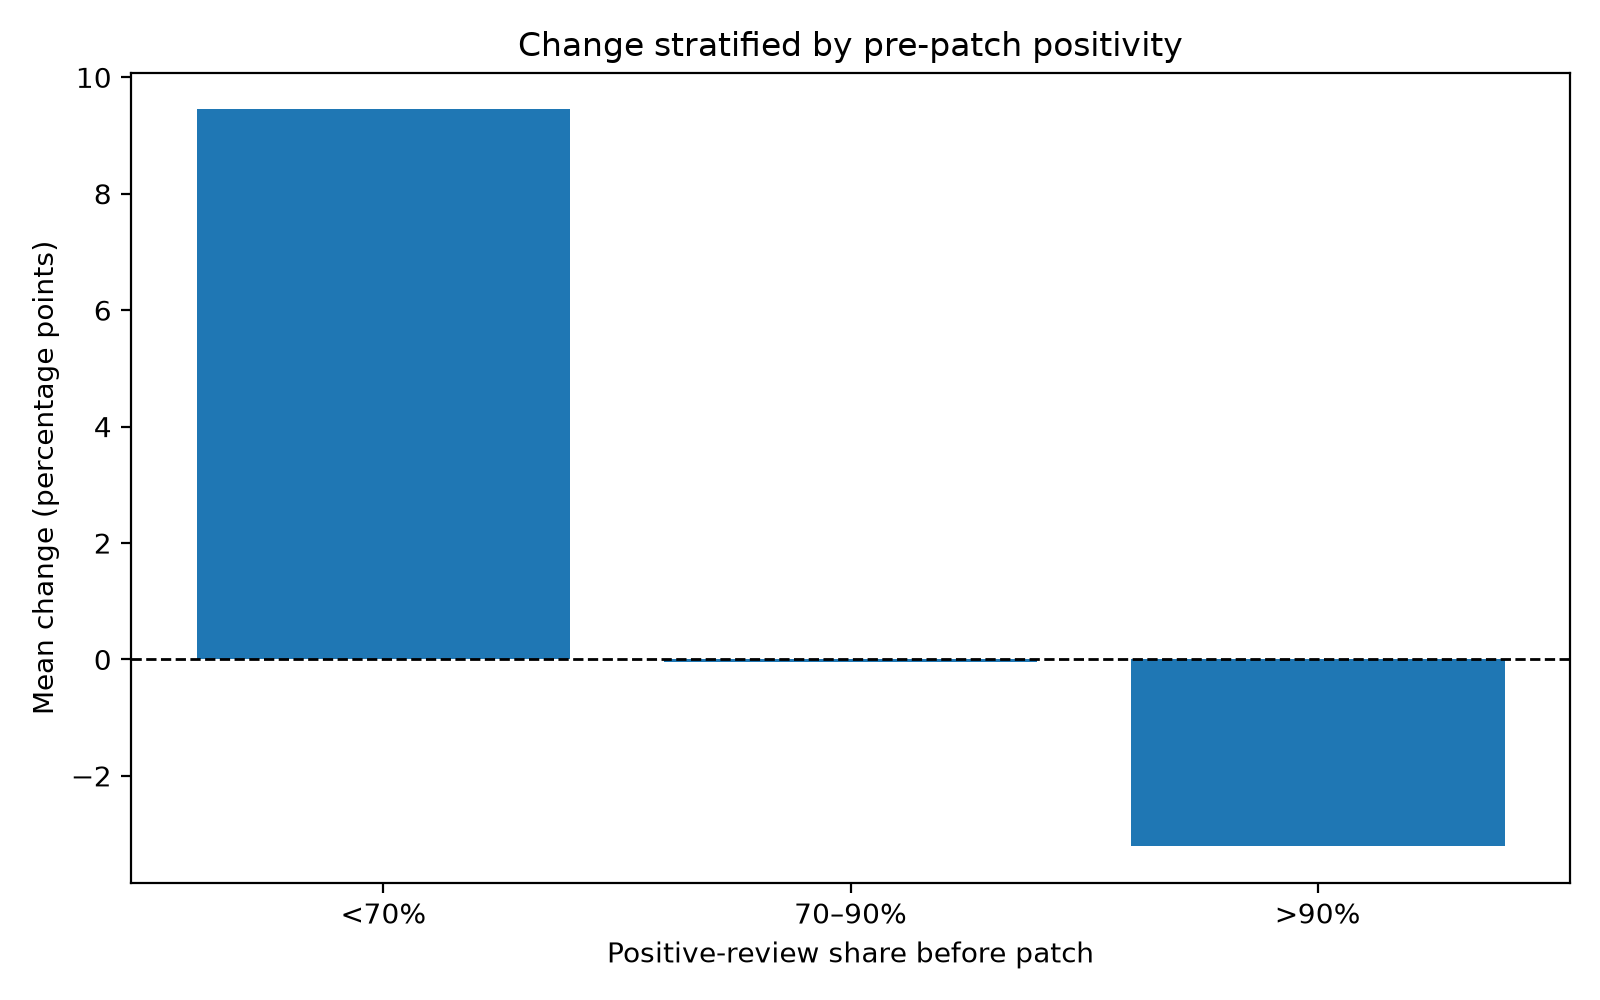

In [6]:
for filename in [
    'patch_impact_change_distribution.png',
    'patch_impact_by_launch.png',
    'patch_impact_by_before_positivity.png',
]:
    figure = FIG / filename
    if figure.exists():
        print(filename)
        display(Image(filename=str(figure)))
    else:
        print(f'Missing figure: {figure}')

## Interpretation and limitations
- The game-level mean weights each game equally after averaging its eligible patch comparisons.
- The confidence interval bootstraps games, not individual patch events.
- Early-launch comparisons show larger average declines.
- High pre-patch positivity is followed by larger declines, consistent with regression to the mean.
- These observational comparisons do not establish a causal patch effect.
- Refund-window share is unavailable from the three-column review input.